In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
import re

In [4]:
file_path_train = '/content/drive/My Drive/Colab Notebooks/Statistical Consulting/'

In [5]:
# Load the dataset
df = pd.read_excel(file_path_train + 'output.xlsx')

# Replace special missing values
df.replace(['n.a.', 'n.s.'], np.nan, inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(df.shape)  # Should give (total_rows, total_columns)

# Define features (X) and target variable (y)
X = df.drop(['Company name Latin alphabet', 'Status Updated'], axis=1)
y = np.where(df['Status Updated'] == 'Active', 1, 0)

# Rename problematic column
X = X.rename(columns={'NACE Rev. 2, core code (4 digits)': 'NACE'})

# One-hot encode categorical features
categorical_cols = ['Quoted', 'Branch', 'Woco', 'NACE',
                    'Consolidation code', 'Standardized country']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Fix column names
X.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', col) for col in X.columns]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -------------------------
# Impute missing values
# -------------------------

def impute_median_by_dummy_group(df, dummy_prefix, impute_cols):
    dummy_cols = [col for col in df.columns if col.startswith(dummy_prefix)]
    for dummy_col in dummy_cols:
        for impute_col in impute_cols:
            median_val = df.loc[df[dummy_col] == 1, impute_col].median()
            df.loc[(df[dummy_col] == 1) & (df[impute_col].isnull()), impute_col] = median_val
    return df

impute_cols = X_train.select_dtypes(include=['number']).columns
X_train = impute_median_by_dummy_group(X_train, 'NACE_', impute_cols)
X_test = impute_median_by_dummy_group(X_test, 'NACE_', impute_cols)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)




(5506, 62)
(3854, 169) (3854,)
(1652, 169) (1652,)


In [6]:
# -------------------------
# Hyperparameter Optimization with Optuna
# -------------------------

!pip install optuna
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

def objective(trial):
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }

    model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss')

    # Use ROC AUC for classification scoring
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    return score.mean()  # maximize AUC

# Create Optuna study
study = optuna.create_study(direction='maximize')  # because AUC should be maximized!
study.optimize(objective, n_trials=50, timeout=600)  # 50 trials or 10 minutes

# Best hyperparameters
best_params = study.best_params
print("Best parameters from Optuna:", best_params)


[I 2025-04-29 11:53:31,200] A new study created in memory with name: no-name-9da263be-4a7e-41dd-b9fd-dc2a5bc134fa
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:53:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:53:32] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:53:32] WARNING: /workspace/src/learner.c

Best parameters from Optuna: {'n_estimators': 286, 'learning_rate': 0.04347816724553037, 'max_depth': 8, 'subsample': 0.9386957891796358, 'colsample_bytree': 0.6697442650303416}


In [8]:
# -------------------------
# Train Best Model
# -------------------------

best_model = xgb.XGBClassifier(
    **best_params,
    tree_method='hist',
    device='cuda',
    random_state=42,
    eval_metric='logloss'
)

best_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6697442650303416, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.04347816724553037,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=286, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [9]:
# -------------------------
# Predictions and Metrics
# -------------------------

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predict probabilities (not labels!)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# You can still compute MSE on probabilities if you want
mse = mean_squared_error(y_test, y_pred_proba)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_proba)

print(f"Optimized XGBoost MSE: {mse}")
print(f"Optimized XGBoost RMSE: {rmse}")
print(f"Mean Absolute Error: {mae}")

# Cross-validation performance (still use ROC AUC)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')
mean_cv_auc = cv_scores.mean()

print(f"Cross-validated ROC AUC: {mean_cv_auc}")


Optimized XGBoost MSE: 0.1585528403520584
Optimized XGBoost RMSE: 0.39818694146350203
Mean Absolute Error: 0.30467528104782104
Cross-validated ROC AUC: 0.8384121623023137


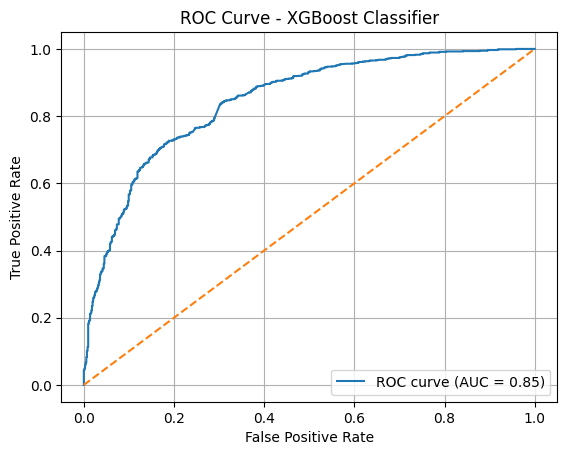

ROC AUC Score: 0.8457241460426075


In [10]:
# -------------------------
# ROC Curve and AUC
# -------------------------

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Classifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()

print(f"ROC AUC Score: {roc_auc}")


In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np


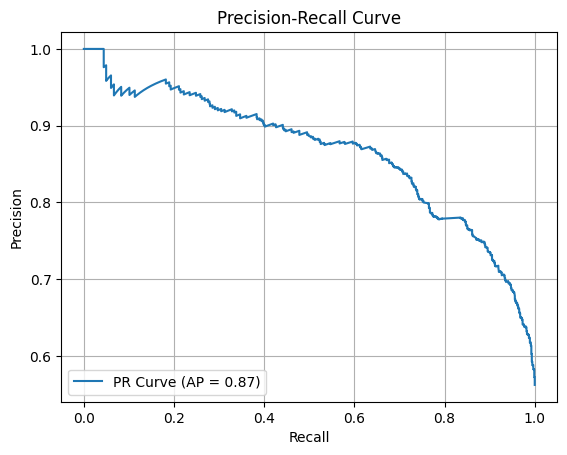

Precision-Recall AUC (Average Precision Score): 0.8661


In [13]:
# Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AP = {pr_auc:.2f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show()

print(f"Precision-Recall AUC (Average Precision Score): {pr_auc:.4f}")


In [14]:
# ROC curve to get FPR, TPR and thresholds
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)

# Compute TSS for each threshold
tss_scores = tpr - fpr  # Equivalent to sensitivity + specificity - 1
best_tss_idx = np.argmax(tss_scores)
best_threshold_tss = thresholds_roc[best_tss_idx]
best_tss_value = tss_scores[best_tss_idx]

print(f"Best threshold according to TSS: {best_threshold_tss:.4f}")
print(f"Best TSS value: {best_tss_value:.4f}")


Best threshold according to TSS: 0.6643
Best TSS value: 0.5385


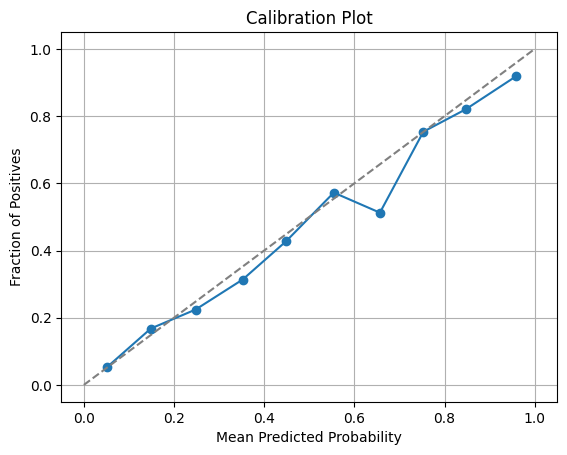

In [15]:
# Calibration plot
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10, strategy='uniform')

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Perfect calibration line
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.grid()
plt.show()


In [16]:
!pip install shap
import shap

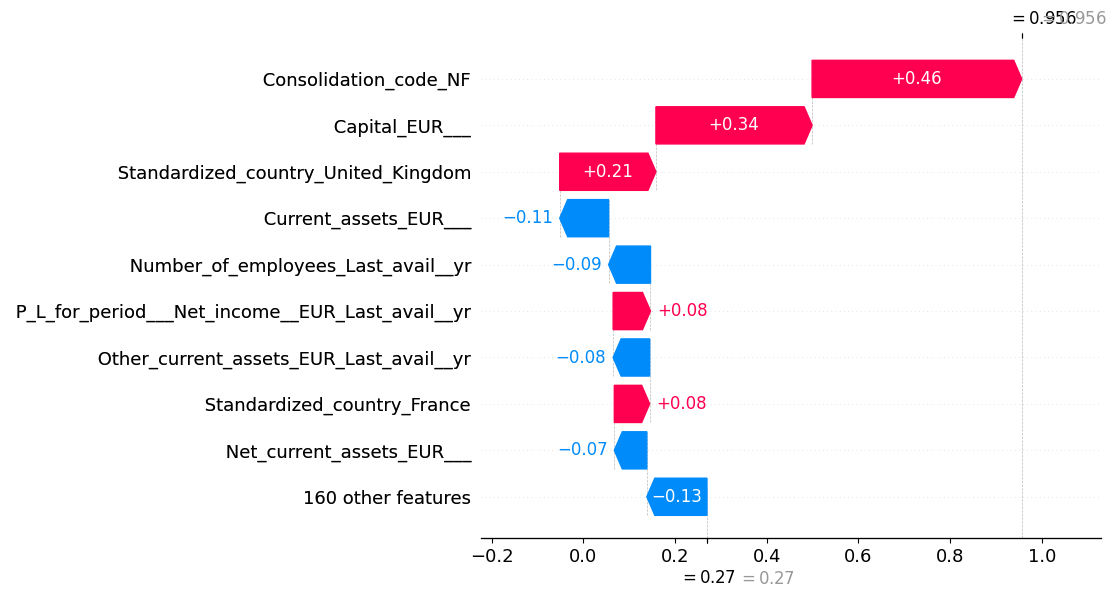

In [20]:
# Recompute if needed
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Choose observation index
index = 0

# Clean waterfall plot using positional arguments only
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,              # base value
    shap_values[index],                    # SHAP values for observation
    X_test.iloc[index],                    # feature values for observation
    feature_names=X_test.columns,          # feature names
    max_display=10                         # optional: show top 10 features only
)

In [21]:
company_names = df.loc[X_test.index, 'Company name Latin alphabet'].values
firm_explanations = {}

for i, name in enumerate(company_names):
    shap_row = shap_values[i]
    feature_contributions = list(zip(X_test.columns, shap_row))

    # Sort by absolute SHAP value
    sorted_features = sorted(
        feature_contributions, key=lambda x: abs(x[1]), reverse=True
    )

    # Take top 5 features
    top_5 = [{'feature': feat, 'shap_value': val} for feat, val in sorted_features[:5]]

    firm_explanations[name] = {
        'predicted_proba': y_pred_proba[i],
        'top_features': top_5
    }

In [22]:
from itertools import islice

# Print first 5 items in the dictionary
for company, data in islice(firm_explanations.items(), 5):
    print(f"Company: {company}")
    print(f"  Predicted Probability: {data['predicted_proba']:.4f}")
    print("  Top Features:")
    for feat in data['top_features']:
        print(f"    - {feat['feature']}: {feat['shap_value']:.4f}")
    print("-" * 40)


Company: MOON WEARABLES DA
  Predicted Probability: 0.7224
  Top Features:
    - Consolidation_code_NF: 0.4573
    - Capital_EUR___: 0.3407
    - Standardized_country_United_Kingdom: 0.2099
    - Current_assets_EUR___: -0.1066
    - Number_of_employees_Last_avail__yr: -0.0914
----------------------------------------
Company: HUAWEI TECHNOLOGIES RESEARCH & DEVELOPMENT (UK) LIMITED
  Predicted Probability: 0.9635
  Top Features:
    - Capital_EUR___: 1.0257
    - Tangible_fixed_assets_EUR_Last_avail__yr: -0.4990
    - Of_which_cash_and_cash_equivalent_EUR_Last_avail__yr: 0.4528
    - Number_of_employees_Last_avail__yr: 0.3949
    - Other_current_assets_EUR_Last_avail__yr: 0.3528
----------------------------------------
Company: ORECON LIMITED
  Predicted Probability: 0.0776
  Top Features:
    - Capital_EUR___: -1.6660
    - Standardized_country_United_Kingdom: -0.3809
    - Number_of_employees_Last_avail__yr: -0.3206
    - Non_current_assets_EUR___: 0.2959
    - Of_which_cash_and_cash_e

In [25]:
import pickle

with open(file_path_train + 'firm_explanations.pkl', 'wb') as f:
    pickle.dump(firm_explanations, f)